In [8]:
import pypsa
import pandas as pd
import numpy as np

from pathlib import Path

idx = pd.IndexSlice

In [301]:
net = pypsa.Network(
    Path.cwd().parent / 'resources' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3000.nc'
    )

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [302]:
tyndp_heating = pd.DataFrame(
    {
        ("Reference", "2019"): {
            "Hybrid heat pump": 0.02, 
            "Electric heat pump": 0.13,
            "Methane boiler": 0.37,
            "Hydrogen boiler": 0.00,
            "Other technologies": 0.48,
        },
        ("Distributed Energy", "2040"): {
            "Hybrid heat pump": 0.05,
            "Electric heat pump": 0.50,
            "Methane boiler": 0.12,
            "Hydrogen boiler": 0.02,
            "Other technologies": 0.31,
        },
        ("Distributed Energy", "2050"): {
            "Hybrid heat pump": 0.07,
            "Electric heat pump": 0.63,
            "Methane boiler": 0.03,
            "Hydrogen boiler": 0.03,
            "Other technologies": 0.25,
        },
        ("Global Ambition", "2040"): {
            "Hybrid heat pump": 0.11,
            "Electric heat pump": 0.37,
            "Methane boiler": 0.14,
            "Hydrogen boiler": 0.05,
            "Other technologies": 0.33,
        },
        ("Global Ambition", "2050"): {
            "Hybrid heat pump": 0.13,
            "Electric heat pump": 0.50,
            "Methane boiler": 0.05,
            "Hydrogen boiler": 0.05,
            "Other technologies": 0.28,
        },
    }
).mul(100.)

In [406]:
district_heating_supply = {
    "Methane": {
        ("National Trends+", 2030): 196,
        ("Distributed Energy", 2040): 185,
    },
    "Biofuels": {
        ("National Trends+", 2030): 141,
        ("Distributed Energy", 2040): 132,
    },
    "Solids": {
        ("National Trends+", 2030): 20,
        ("Distributed Energy", 2040): 102,
    },
    "Hydrogen": {
        ("National Trends+", 2030): 5,
        ("Distributed Energy", 2040): 91,
    },
    "Electricity": {
        ("National Trends+", 2030): 35,
        ("Distributed Energy", 2040): 68,
    },
    "Liquids": {
        ("National Trends+", 2030): 2,
        ("Distributed Energy", 2040): 6,
    },
    "Others*": {
        ("National Trends+", 2030): 65,
        ("Distributed Energy", 2040): 109,
    },
}

df_district_heating_supply = pd.DataFrame(district_heating_supply).T
df_district_heating_supply.columns = pd.MultiIndex.from_tuples(df_district_heating_supply.columns, names=["Scenario", "Year"])

df_district_heating_supply




Scenario    National Trends+      Distributed Energy      Global Ambition     
Year                    2030 2040               2040 2050            2040 2050
Methane                  196  149                185  102             167   84
Biofuels                 141  149                132  103             123   96
Solids                    20    0                102   72              94   71
Hydrogen                   5   41                 91   76              87   68
Electricity               35  144                 68   83              61   71
Liquids                    2    2                  6    6               6    6
Others*                   65   92                109  107              97   86

In [303]:
tyndp_heating

Reference Distributed Energy       Global Ambition      
                        2019               2040  2050            2040  2050
Hybrid heat pump         2.0                5.0   7.0            11.0  13.0
Electric heat pump      13.0               50.0  63.0            37.0  50.0
Methane boiler          37.0               12.0   3.0            14.0   5.0
Hydrogen boiler          0.0                2.0   3.0             5.0   5.0
Other technologies      48.0               31.0  25.0            33.0  28.0

In [304]:
def get_efficiency(n, link):

    try:
        if link in (effs := n.links_t.efficiency).columns:
            return effs.loc[:, link].mean()
        elif 'CHP' in link:
            return n.links.loc[link, 'efficiency2']
        else:
            return n.links.loc[link, 'efficiency']
    except KeyError:
        return 0.

In [320]:
ex0 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'existing_heating_distribution_base_s_50_2035.csv',
    header=[0,1], index_col=0
)

existing = pd.concat([
    ex0.T.loc[idx[['residential rural', 'services rural']]].groupby(level=1).sum().T,
    ex0.T.loc[idx[['residential urban decentral', 'services urban decentral']]].groupby(level=1).sum().T,
    ],
    axis=1,
    keys=['rural', 'urban decentral']
)

In [306]:
'''
    p_nom_decentral = installed.loc[:, idx['urban decentral']]

    etas = p_nom_decentral.apply(
        lambda col: col.index.map(
            lambda idx: get_efficiency(n, idx + ' urban decentral ' + col.name)
            )
    )

    decentral_loads_idx = (
        n.loads.index[n.loads.carrier.isin(['urban decentral heat'])]
        .intersection(n.loads_t.p_set.columns)
    )
    eff_p_nom_decentral = p_nom_decentral.mul(etas, axis=0).rename(
        columns={'air heat pump': 'heat pump'}
        ).loc[to_ac_bus(decentral_loads_idx)]

    decentral_peaks = n.loads_t.p_set.loc[:, decentral_loads_idx].max()
    decentral_peaks.index = eff_p_nom_decentral.index
    excess_capacity = decentral_peaks.div(eff_p_nom_decentral.sum(axis=1))

    eff_p_nom_decentral = eff_p_nom_decentral.mul(excess_capacity, axis=0)
    # print(eff_p_nom_decentral.head())

    # eff_p_nom_total = eff_p_nom_rural.add(eff_p_nom_decentral, fill_value=0)

    # print(eff_p_nom_total)
    # loads_idx = n.loads.index[n.loads.carrier.isin(['rural heat', 'urban decentral heat'])]
    # kloads = n.loads_t.p_set.loc[:, loads_idx.intersection(n.loads_t.p_set.columns)].max().sum()
    # print(loads / 1e3)
    # print(eff_p_nom_total.sum(axis=1).sum() / 1e3)

    # shares = eff_p_nom_total.div(eff_p_nom_total.sum(axis=1), axis=0)
    # print(shares)

    # return shares.loc[:, shares.replace(np.nan, 0).sum() > 0]

    return pd.concat([eff_p_nom_rural, eff_p_nom_decentral], axis=1, keys=['rural', 'urban decentral'])
'''
pass

In [307]:
target_2040_gas = tyndp_heating.loc['Methane boiler', ('Distributed Energy', '2040')]
target_2040_heat_pump = tyndp_heating.loc[['Electric heat pump', 'Hybrid heat pump'], ('Distributed Energy', '2040')].sum()
target_2040_biomass = 100. - target_2040_gas - target_2040_heat_pump

In [308]:
print(
    target_2040_gas,
    target_2040_heat_pump,
    target_2040_biomass,
)


12.0 55.0 33.0


In [309]:
def interpolate_to_target_year(percentage_2025, percentage_2040, year):
    return (year - 2025) / (2040 - 2025) * percentage_2040 + (1 - (year - 2025) / (2040 - 2025)) * percentage_2025

In [310]:
def to_ac_bus(x):
    if isinstance(x, pd.Index):
        return pd.Index([to_ac_bus(i) for i in x])
    return ' '.join(x.split(' ')[:2])


def adjust_heating_capacities(n, installed, target_year):

    n = n.copy()

    ######################################################################################################################

    p_nom_rural = installed.loc[:, idx['rural']].drop(columns=['air heat pump'])

    etas = p_nom_rural.apply(
        lambda col: col.index.map(
            lambda idx: get_efficiency(n, idx + ' rural ' + col.name)
            )
    )
    eff_p_nom_rural = p_nom_rural.mul(etas, axis=0)

    rural_loads_idx = n.loads.index[n.loads.carrier.isin(['rural heat'])]
    rural_peaks = n.loads_t.p_set.loc[:, rural_loads_idx].max()
    rural_peaks.index = eff_p_nom_rural.index

    excess_capacity = rural_peaks.div(eff_p_nom_rural.sum(axis=1))

    current_p_nom_rural = p_nom_rural.mul(excess_capacity, axis=0)
    eff_current_percentage_rural = eff_p_nom_rural.div(eff_p_nom_rural.sum(axis=1), axis=0) * 100

    rural_carriers = [
        'ground heat pump',
        'gas boiler',
        'biomass boiler',
    ]

    for bus in installed.index:

        targets_2040 = {
            'gas boiler': target_2040_gas,
            'heat pump': target_2040_heat_pump,
            'biomass boiler': target_2040_biomass,
        }
        tyndp_carriers = {
            'ground heat pump': 'heat pump',
        }

        bus_served = False

        for carrier in rural_carriers:

            tyndp_carrier = tyndp_carriers.get(carrier, carrier)
            target_2040 = targets_2040[tyndp_carrier]

            current_percentage = eff_current_percentage_rural.loc[bus, carrier]
            current_capacity = current_p_nom_rural.loc[bus, carrier]

            if np.isnan(current_percentage) or current_capacity == 0:
                continue

            target_percentage = interpolate_to_target_year(current_percentage, target_2040, target_year)

            # if carrier == 'ground heat pump':
            #     print(bus, carrier, round(current_percentage), round(target_percentage), round(target_2040))

            factor = target_percentage / current_percentage

            n.links.loc[bus + ' rural ' + carrier, 'p_nom'] = current_capacity * factor
            n.links.loc[bus + ' rural ' + carrier, 'p_nom_extendable'] = False

            ###########   THIS IS WHERE MUST RUN GOES






            ########################################

            bus_served = True

        if not bus_served:
            continue

        # the current scaling above correctly scales the relative capacities but under- or overshoots the total

        def get_rural_dispatch(n, bus):

            load = n.loads_t.p_set.loc[:, f'{bus} rural heat']
            relative_load = load.div(load.max())

            ground_hp_dispatch = n.links_t.efficiency.loc[
                :, f'{bus} rural ground heat pump'
                ].mul(n.links.loc[f'{bus} rural ground heat pump', 'p_nom'])

            biomass_dispatch = pd.Series(
                n.links.loc[f'{bus} rural biomass boiler', 'p_nom'] *
                n.links.efficiency.loc[f'{bus} rural biomass boiler'],
                index=n.snapshots
                )

            gas_dispatch = pd.Series(
                n.links.loc[f'{bus} rural gas boiler', 'p_nom'] *
                n.links.efficiency.loc[f'{bus} rural gas boiler'],
                index=n.snapshots
                )

            dispatch = pd.DataFrame(
                {
                    'ground heat pump': ground_hp_dispatch,
                    'biomass boiler': biomass_dispatch,
                    'gas boiler': gas_dispatch,
                }
            )
            return dispatch.mul(relative_load, axis=0)


        dispatch = get_rural_dispatch(n, bus)
        load = n.loads_t.p_set.loc[:, f'{bus} rural heat']

        supply_deviation = dispatch.sum(axis=1).div(load, axis=0).replace(np.inf, 0.)

        # Calculate weight-loaded average supply_deviation
        weighted_avg_supply_deviation = (supply_deviation * load).sum() / load.sum()

        n.links.loc[f'{bus} rural ' + pd.Index(rural_carriers), 'p_nom'] /= weighted_avg_supply_deviation

        # the remaining deviation is solved by adjusting the load
        # n.loads_t.p_set.loc[:, f'{bus} rural heat'] = get_rural_dispatch(n, bus).sum(axis=1)

        # print('small error incurred here')

    ######################################################################################################################

    p_nom_udh = installed.loc[:, idx['urban decentral']]# .drop(columns=['air heat pump'])

    etas = p_nom_udh.apply(
        lambda col: col.index.map(
            lambda idx: get_efficiency(n, idx + ' urban decentral ' + col.name)
            )
    )
    eff_p_nom_udh = p_nom_udh.mul(etas, axis=0)
    # print(eff_p_nom_udh.index)

    udh_loads_idx = n.loads.index[n.loads.carrier.isin(['urban decentral heat'])]
    udh_loads_idx_exist = udh_loads_idx.intersection(n.loads_t.p_set.columns)

    eff_p_nom_udh = eff_p_nom_udh.loc[to_ac_bus(udh_loads_idx_exist)]

    udh_peaks = n.loads_t.p_set.loc[:, udh_loads_idx_exist].max()

    udh_peaks.index = eff_p_nom_udh.index

    excess_capacity = udh_peaks.div(eff_p_nom_udh.sum(axis=1))

    current_p_nom_udh = p_nom_udh.mul(excess_capacity, axis=0)
    eff_current_percentage_udh = eff_p_nom_udh.div(eff_p_nom_udh.sum(axis=1), axis=0) * 100

    '''
    print('=====================================')
    print('excess capacity')
    print(excess_capacity.head())
    print('=====================================')
    print('effective percentage urban decentral')
    print(eff_current_percentage_udh.head())
    print('=====================================')
    print('urban decentral capacities')
    print(p_nom_udh.head())
    print('=====================================')
    '''

    udh_carriers = [
        'air heat pump',
        'gas boiler',
        'biomass boiler',
    ]

    for bus in installed.index:

        targets_2040 = {
            'gas boiler': target_2040_gas,
            'heat pump': target_2040_heat_pump,
            'biomass boiler': target_2040_biomass,
        }
        tyndp_carriers = {
            'air heat pump': 'heat pump',
        }

        bus_served = False

        for carrier in udh_carriers:

            tyndp_carrier = tyndp_carriers.get(carrier, carrier)
            target_2040 = targets_2040[tyndp_carrier]

            try:
                current_percentage = eff_current_percentage_udh.loc[bus, carrier]
            except KeyError:
                continue

            current_capacity = current_p_nom_udh.loc[bus, carrier]

            if np.isnan(current_percentage) or current_capacity == 0 or not bus + ' urban decentral heat' in n.loads_t.p_set.columns:
                continue

            target_percentage = interpolate_to_target_year(current_percentage, target_2040, target_year)

            # if carrier == 'air heat pump':
            #     print(bus, carrier, round(current_percentage), round(target_percentage), round(target_2040))

            factor = target_percentage / current_percentage

            n.links.loc[bus + ' urban decentral ' + carrier, 'p_nom'] = current_capacity * factor

            ###########   THIS IS WHERE MUST RUN GOES





            ########################################

            bus_served = True

        if not bus_served:
            continue

        # the current scaling above correctly scales the relative capacities but under- or overshoots the total

        def get_urban_decentral_dispatch(n, bus):

            load = n.loads_t.p_set.loc[:, f'{bus} urban decentral heat']
            relative_load = load.div(load.max())

            air_hp_dispatch = n.links_t.efficiency.loc[
                :, f'{bus} urban decentral air heat pump'
                ].mul(n.links.loc[f'{bus} urban decentral air heat pump', 'p_nom'])

            biomass_dispatch = pd.Series(
                n.links.loc[f'{bus} urban decentral biomass boiler', 'p_nom'] *
                n.links.efficiency.loc[f'{bus} urban decentral biomass boiler'],
                index=n.snapshots
                )

            gas_dispatch = pd.Series(
                n.links.loc[f'{bus} urban decentral gas boiler', 'p_nom'] *
                n.links.efficiency.loc[f'{bus} urban decentral gas boiler'],
                index=n.snapshots
                )

            dispatch = pd.DataFrame(
                {
                    'air heat pump': air_hp_dispatch,
                    'biomass boiler': biomass_dispatch,
                    'gas boiler': gas_dispatch,
                }
            )
            return dispatch.mul(relative_load, axis=0)


        dispatch = get_urban_decentral_dispatch(n, bus)
        load = n.loads_t.p_set.loc[:, f'{bus} urban decentral heat']

        supply_deviation = dispatch.sum(axis=1).div(load, axis=0).replace(np.inf, 0.)

        # Calculate weight-loaded average supply_deviation
        weighted_avg_supply_deviation = (supply_deviation * load).sum() / load.sum()

        n.links.loc[f'{bus} urban decentral ' + pd.Index(udh_carriers), 'p_nom'] /= weighted_avg_supply_deviation

        # n.loads_t.p_set.loc[:, f'{bus} urban decentral heat'] = get_urban_decentral_dispatch(n, bus).sum(axis=1)

    # return eff_p_nom_rural.head()
    return n, eff_current_percentage_rural


m, eff_percentages = adjust_heating_capacities(net, existing, 2025) # using technology efficiencies turn capacities into heat provision shares

In [311]:
existing.index

Index(['AL0 0', 'AT0 0', 'BA0 0', 'BE0 0', 'BG0 0', 'CH0 0', 'CZ0 0', 'DE0 0',
       'DE0 1', 'DE0 2', 'DE0 3', 'DE0 4', 'DE0 5', 'DK0 0', 'DK1 0', 'EE0 0',
       'ES0 0', 'ES6 0', 'FI1 0', 'FR0 0', 'FR0 1', 'FR0 2', 'FR0 3', 'FR0 4',
       'FR5 0', 'GB2 0', 'GB2 1', 'GB3 0', 'GR0 0', 'HR0 0', 'HU0 0', 'IE3 0',
       'IT0 0', 'IT0 1', 'IT4 0', 'LT0 0', 'LU0 0', 'LV0 0', 'ME0 0', 'MK0 0',
       'NL0 0', 'NO1 0', 'PL0 0', 'PT0 0', 'RO0 0', 'RS0 0', 'SE1 0', 'SI0 0',
       'SK0 0', 'XK0 0'],
      dtype='object', name='name')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


snapshot
2024-01-01 00:00:00    0.994402
2024-01-01 03:00:00    0.994376
2024-01-01 06:00:00    0.994350
2024-01-01 09:00:00    0.994302
2024-01-01 12:00:00    0.994264
dtype: float64


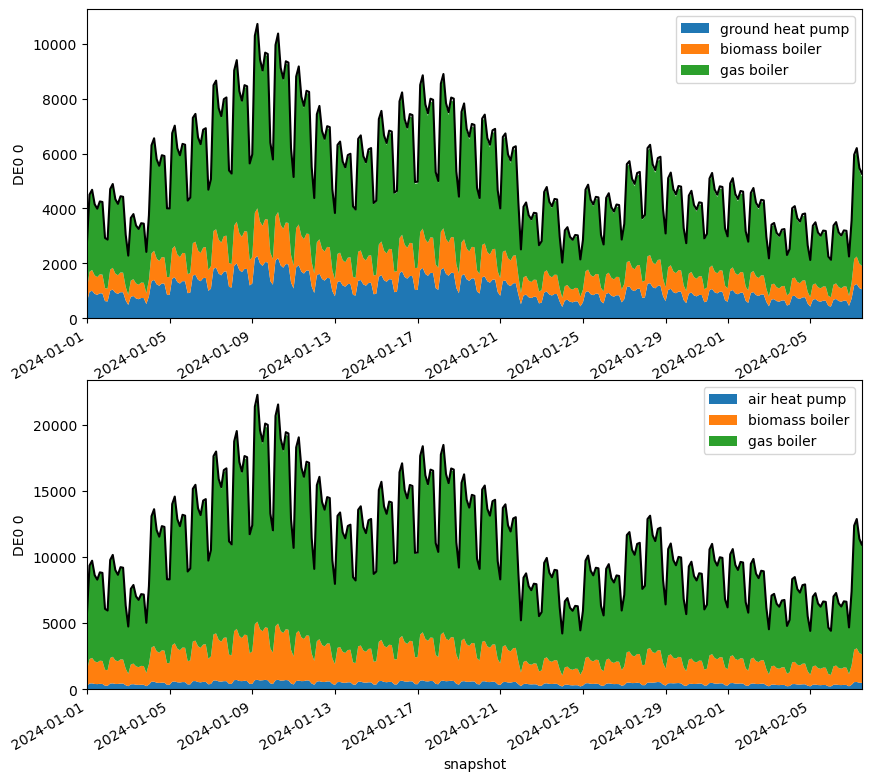

In [318]:
import matplotlib.pyplot as plt

# for bus in existing.index:
for bus in ['DE0 0']:

    fig, axs = plt.subplots(2, 1, figsize=(10, 10))


    # print(m.links.loc[f'{bus} rural air heat pump', 'p_nom'])
    # print(m.links.loc[f'{bus} rural ground heat pump', 'p_nom'])
    # print(m.links.loc[f'{bus} rural biomass boiler', 'p_nom'])
    # print(m.links.loc[f'{bus} rural gas boiler', 'p_nom'])

    load_rural = m.loads_t.p_set.loc[:, f'{bus} rural heat']
    axs[0].plot(load_rural.index, load_rural.values, label='rural heat load', color='k')

    # air_hp_dispatch = m.links_t.efficiency.loc[
    #     :, f'{bus} rural air heat pump'
    #     ].mul(m.links.loc[f'{bus} rural air heat pump', 'p_nom'])

    ground_hp_dispatch = m.links_t.efficiency.loc[
        :, f'{bus} rural ground heat pump'
        ].mul(m.links.loc[f'{bus} rural ground heat pump', 'p_nom'])

    biomass_dispatch = pd.Series(
        m.links.loc[f'{bus} rural biomass boiler', 'p_nom'] *
        m.links.efficiency.loc[f'{bus} rural biomass boiler'],
        index=m.snapshots
        )

    gas_dispatch = pd.Series(
        m.links.loc[f'{bus} rural gas boiler', 'p_nom'] *
        m.links.efficiency.loc[f'{bus} rural gas boiler'],
        index=m.snapshots
        )



    relative_load = m.loads_t.p_set.loc[:, f'{bus} rural heat'].div(load_rural.max())

    dispatch = pd.DataFrame(
        {
            # 'air heat pump': air_hp_dispatch,
            'ground heat pump': ground_hp_dispatch,
            'biomass boiler': biomass_dispatch,
            'gas boiler': gas_dispatch,
        }
    ).mul(relative_load, axis=0)

    dispatch.plot.area(ax=axs[0], linewidth=0)

    print(dispatch.sum(axis=1).div(load_rural, axis=0).head())
    axs[0].set_ylabel(bus)

    # Urban decentral heating
    try:
        load_urban = m.loads_t.p_set.loc[:, f'{bus} urban decentral heat']
    except KeyError:
        plt.show()
        continue

    axs[1].plot(load_urban.index, load_urban.values, label='urban decentral heat load', color='k')

    air_hp_dispatch_urban = m.links_t.efficiency.loc[
        :, f'{bus} urban decentral air heat pump'
        ].mul(m.links.loc[f'{bus} urban decentral air heat pump', 'p_nom'])

    biomass_dispatch_urban = pd.Series(
        m.links.loc[f'{bus} urban decentral biomass boiler', 'p_nom'] *
        m.links.efficiency.loc[f'{bus} urban decentral biomass boiler'],
        index=m.snapshots
        )

    gas_dispatch_urban = pd.Series(
        m.links.loc[f'{bus} urban decentral gas boiler', 'p_nom'] *
        m.links.efficiency.loc[f'{bus} urban decentral gas boiler'],
        index=m.snapshots
        )

    relative_load_urban = m.loads_t.p_set.loc[:, f'{bus} urban decentral heat'].div(load_urban.max())

    dispatch_urban = pd.DataFrame(
        {
            'air heat pump': air_hp_dispatch_urban,
            'biomass boiler': biomass_dispatch_urban,
            'gas boiler': gas_dispatch_urban,
        }
    ).mul(relative_load_urban, axis=0)

    dispatch_urban.plot.area(ax=axs[1], linewidth=0)

    # print(dispatch_urban.sum(axis=1).div(load_urban, axis=0).head())
    axs[1].set_ylabel(bus)

    for ax in axs:
        ax.set_xlim(dispatch.index[0], dispatch.index[300])

    plt.show()

In [300]:
existing

rural                                                \
technology air heat pump biomass boiler    gas boiler ground heat pump   
name                                                                     
AL0 0                0.0       0.000000      0.000000         0.000000   
AT0 0                0.0    5076.759168   3891.708788      1077.000000   
BA0 0                0.0       0.000000      0.000000         0.000000   
BE0 0                0.0     196.871112   1298.599182        61.000000   
BG0 0                0.0    1395.159666     39.196760        45.000000   
CH0 0                0.0       0.000000      0.000000       849.000000   
CZ0 0                0.0    2188.464371   2487.135503       263.000000   
DE0 0                0.0    1645.780847   5419.921904       538.803354   
DE0 1                0.0    1739.759297   5729.413813       271.526353   
DE0 2                0.0     838.874900   2762.601382       824.457515   
DE0 3                0.0    1530.846620   5041.417962       387.284409   
DE0 4                0.0     708.848367   2334.395129       754.780866   
DE0 5                0.0    2284.603848   7523.707944       513.147504   
DK0 0                0.0     356.813965    262.651697       241.492649   
DK1 0                0.0     156.215625    114.990732       139.507351   
EE0 0                0.0     814.527253     64.435813       100.000000   
ES0 0                0.0    3611.547674   9282.776525        15.738428   
ES6 0                0.0      25.022071     64.314337         0.261572   
FI1 0                0.0    1541.785536      0.000000       580.000000   
FR0 0                0.0    1720.393833   2385.512622       708.238058   
FR0 1                0.0    1653.982111   2293.425568       446.472325   
FR0 2                0.0    3634.933312   5040.229238       288.931088   
FR0 3                0.0    1222.279574   1694.823183       298.489931   
FR0 4                0.0    2196.274707   3045.373063       219.710325   
FR5 0                0.0     229.520801    318.255482         8.158273   
GB2 0                0.0     247.067339  12118.532160        71.663159   
GB2 1                0.0     199.482331   9784.510812       132.791302   
GB3 0                0.0      55.112071   2703.220150         5.545539   
GR0 0                0.0    1612.725346    395.660147         0.000000   
HR0 0                0.0    1654.225427   3487.173701         0.000000   
HU0 0                0.0    1592.481022   6214.631551        35.000000   
IE3 0                0.0      72.564352   1478.669823        30.000000   
IT0 0                0.0    9693.773181  17020.824041       257.833308   
IT0 1                0.0    6940.737706  12186.903180       327.290904   
IT4 0                0.0    1233.473932   2165.796782        14.875788   
LT0 0                0.0    1304.597413      0.000000        20.000000   
LU0 0                0.0      10.528185     65.490286         1.000000   
LV0 0                0.0    1625.390287    499.768316         0.000000   
ME0 0                0.0       0.000000      0.000000         0.000000   
MK0 0                0.0       0.000000      0.000000         0.000000   
NL0 0                0.0     122.624328   4575.090076       849.000000   
NO1 0                0.0     778.001295      0.000000       334.000000   
PL0 0                0.0    7942.671886   3286.540428        40.000000   
PT0 0                0.0    2494.334815   1618.513108        64.000000   
RO0 0                0.0   10600.931401   7483.648393         0.000000   
RS0 0                0.0       0.000000      0.000000         0.000000   
SE1 0                0.0    1141.448219    122.280728      4813.000000   
SI0 0                0.0    1436.182364    170.618635        56.000000   
SK0 0                0.0     110.399586   3366.351009        15.000000   
XK0 0                0.0       0.000000      0.000000         0.000000   

                                          urban decentral                 \
technology    oil bo

In [190]:
eff_percentages.head()

technology,biomass boiler,gas boiler,ground heat pump,oil boiler,resistive heater
name,,,,,
AL0 0,NaN,NaN,NaN,NaN,NaN
AT0 0,36.260313,32.263438,31.476249,0.0,0.0
BA0 0,NaN,NaN,NaN,NaN,NaN
BE0 0,9.994539,76.521107,13.484353,0.0,0.0
BG0 0,84.713098,2.762499,12.524403,0.0,0.0


In [158]:
existing

rural                                                \
technology air heat pump biomass boiler    gas boiler ground heat pump   
name                                                                     
AL0 0                0.0       0.000000      0.000000         0.000000   
AT0 0                0.0    5076.759168   3891.708788      1077.000000   
BA0 0                0.0       0.000000      0.000000         0.000000   
BE0 0                0.0     196.871112   1298.599182        61.000000   
BG0 0                0.0    1395.159666     39.196760        45.000000   
CH0 0                0.0       0.000000      0.000000       849.000000   
CZ0 0                0.0    2188.464371   2487.135503       263.000000   
DE0 0                0.0    1645.780847   5419.921904       538.803354   
DE0 1                0.0    1739.759297   5729.413813       271.526353   
DE0 2                0.0     838.874900   2762.601382       824.457515   
DE0 3                0.0    1530.846620   5041.417962       387.284409   
DE0 4                0.0     708.848367   2334.395129       754.780866   
DE0 5                0.0    2284.603848   7523.707944       513.147504   
DK0 0                0.0     356.813965    262.651697       241.492649   
DK1 0                0.0     156.215625    114.990732       139.507351   
EE0 0                0.0     814.527253     64.435813       100.000000   
ES0 0                0.0    3611.547674   9282.776525        15.738428   
ES6 0                0.0      25.022071     64.314337         0.261572   
FI1 0                0.0    1541.785536      0.000000       580.000000   
FR0 0                0.0    1720.393833   2385.512622       708.238058   
FR0 1                0.0    1653.982111   2293.425568       446.472325   
FR0 2                0.0    3634.933312   5040.229238       288.931088   
FR0 3                0.0    1222.279574   1694.823183       298.489931   
FR0 4                0.0    2196.274707   3045.373063       219.710325   
FR5 0                0.0     229.520801    318.255482         8.158273   
GB2 0                0.0     247.067339  12118.532160        71.663159   
GB2 1                0.0     199.482331   9784.510812       132.791302   
GB3 0                0.0      55.112071   2703.220150         5.545539   
GR0 0                0.0    1612.725346    395.660147         0.000000   
HR0 0                0.0    1654.225427   3487.173701         0.000000   
HU0 0                0.0    1592.481022   6214.631551        35.000000   
IE3 0                0.0      72.564352   1478.669823        30.000000   
IT0 0                0.0    9693.773181  17020.824041       257.833308   
IT0 1                0.0    6940.737706  12186.903180       327.290904   
IT4 0                0.0    1233.473932   2165.796782        14.875788   
LT0 0                0.0    1304.597413      0.000000        20.000000   
LU0 0                0.0      10.528185     65.490286         1.000000   
LV0 0                0.0    1625.390287    499.768316         0.000000   
ME0 0                0.0       0.000000      0.000000         0.000000   
MK0 0                0.0       0.000000      0.000000         0.000000   
NL0 0                0.0     122.624328   4575.090076       849.000000   
NO1 0                0.0     778.001295      0.000000       334.000000   
PL0 0                0.0    7942.671886   3286.540428        40.000000   
PT0 0                0.0    2494.334815   1618.513108        64.000000   
RO0 0                0.0   10600.931401   7483.648393         0.000000   
RS0 0                0.0       0.000000      0.000000         0.000000   
SE1 0                0.0    1141.448219    122.280728      4813.000000   
SI0 0                0.0    1436.182364    170.618635        56.000000   
SK0 0                0.0     110.399586   3366.351009        15.000000   
XK0 0                0.0       0.000000      0.000000         0.000000   

                                          urban decentral                 \
technology    oil bo

In [130]:
dd = to_shares(net, existing) # using technology efficiencies turn capacities into heat provision shares

In [122]:
dd.head()

rural                                                      \
technology air heat pump biomass boiler   gas boiler    heat pump oil boiler   
AL0 0                NaN            NaN          NaN          NaN        NaN   
AT0 0                0.0    2586.659976  2301.539571  2245.384719        0.0   
BA0 0                NaN            NaN          NaN          NaN        NaN   
BE0 0                0.0     121.817275   932.668564   164.352463        0.0   
BG0 0                0.0    1057.234977    34.476495   156.306837        0.0   

                            urban decentral                               \
technology resistive heater       heat pump biomass boiler    gas boiler   
AL0 0                   NaN             NaN            NaN           NaN   
AT0 0                   0.0      874.588306    2779.438451   2473.068605   
BA0 0                   NaN             NaN            NaN           NaN   
BE0 0                   0.0      295.932533    2185.458865  16732.510107   
BG0 0                   0.0     1071.212897    1319.914621     43.042494   

                                                         
technology ground heat pump oil boiler resistive heater  
AL0 0                   NaN        NaN              NaN  
AT0 0                   0.0        0.0              0.0  
BA0 0                   NaN        NaN              NaN  
BE0 0                   0.0        0.0              0.0  
BG0 0                   0.0        0.0              0.0

In [113]:
existing.head()

rural                                               \
technology air heat pump biomass boiler   gas boiler ground heat pump   
name                                                                    
AL0 0                0.0       0.000000     0.000000              0.0   
AT0 0                0.0    5076.759168  3891.708788           1077.0   
BA0 0                0.0       0.000000     0.000000              0.0   
BE0 0                0.0     196.871112  1298.599182             61.0   
BG0 0                0.0    1395.159666    39.196760             45.0   

                                         urban decentral                 \
technology   oil boiler resistive heater   air heat pump biomass boiler   
name                                                                      
AL0 0          0.000000         0.000000             0.0       0.000000   
AT0 0       6605.883372         0.000000           720.0    7081.240832   
BA0 0          0.000000         0.000000             0.0       0.000000   
BE0 0        947.762418       143.628088           170.0    4107.128888   
BG0 0        911.324663       847.629929          1010.0    4299.840334   

                                                                          
technology    gas boiler ground heat pump    oil boiler resistive heater  
name                                                                      
AL0 0           0.000000              0.0      0.000000         0.000000  
AT0 0        5428.291212              0.0   9214.116628         0.000000  
BA0 0           0.000000              0.0      0.000000         0.000000  
BE0 0       27091.400818              0.0  19772.237582      2996.371912  
BG0 0         120.803240              0.0   2808.675337      2612.370071

In [171]:
import matplotlib.pyplot as plt

n = net.copy()

target_year = 2035



target_capacities = pd.DataFrame(0, index=existing_shares.dropna().index, columns=['rural', 'urban decentral'])


print('target_2040_gas', target_2040_gas)
print('target_2040_heat_pump', target_2040_heat_pump)
print('target_2040_biomass', target_2040_biomass)
print('--------------------------------')

for bus in target_capacities.index:

    current_gas_share = existing_shares.loc[bus, 'gas boiler'] * 100
    target_gas_share = (target_year - 2024) / (2040 - 2024) * (target_2040_gas - current_gas_share) + current_gas_share

    factor_gas = target_gas_share / current_gas_share if current_gas_share > 0 else 0

    print('factor_gas', factor_gas)

    current_heat_pump_share = existing_shares.loc[bus, 'heat pump'] * 100
    target_heat_pump_share = (target_year - 2024) / (2040 - 2024) * (target_2040_heat_pump - current_heat_pump_share) + current_heat_pump_share

    factor_heat_pump = target_heat_pump_share / current_heat_pump_share if current_heat_pump_share > 0 else 0

    print('factor_heat_pump', factor_heat_pump)

    current_biomass_share = existing_shares.loc[bus, 'biomass boiler'] * 100
    target_biomass_share = (target_year - 2024) / (2040 - 2024) * (target_2040_biomass - current_biomass_share) + current_biomass_share

    print('current_biomass_share', current_biomass_share)
    print('target_biomass_share', target_biomass_share)

    factor_biomass = target_biomass_share / current_biomass_share if current_biomass_share > 0 else 0

    print('factor_biomass', factor_biomass)

    if factor_heat_pump > 0:

        links = bus + ' ' + pd.Index(['rural air heat pump', 'rural ground heat pump', 'urban decentral air heat pump'])

        print(links)
        print('before: ', n.links.loc[links, 'p_nom'])

        n.links.loc[
            f'{bus} rural air heat pump', 'p_nom'
        ] = existing.loc[bus, idx['rural', 'air heat pump']] * factor_heat_pump

        n.links.loc[
            f'{bus} rural ground heat pump', 'p_nom'
        ] = existing.loc[bus, idx['rural', 'ground heat pump']] * factor_heat_pump

        n.links.loc[
            f'{bus} urban decentral air heat pump', 'p_nom'
        ] = existing.loc[bus, idx['urban decentral', 'air heat pump']] * factor_heat_pump

        n.links.loc[links, 'p_nom'] *= factor_heat_pump
        print('after: ', n.links.loc[links, 'p_nom'])

    else:
        pass



    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    
    load_rural = n.loads_t.p_set.loc[:, f'{bus} rural heat']
    axs[0].plot(load_rural.index, load_rural.values, label='rural heat load')

    air_hp_dispatch = n.links_t.efficiency.loc[
        :, f'{bus} rural air heat pump'
        ].mul(n.links.loc[f'{bus} rural air heat pump', 'p_nom'])
    
    ground_hp_dispatch = n.links_t.efficiency.loc[
        :, f'{bus} rural ground heat pump'
        ].mul(n.links.loc[f'{bus} rural ground heat pump', 'p_nom'])
    
    load_weight = n.loads_t.p_set.loc[:, f'{bus} rural heat'].div(load_rural.max())
    dispatch = pd.DataFrame(
        {
            'air heat pump': air_hp_dispatch,
            'ground heat pump': ground_hp_dispatch,
        }
    ).mul(load_weight, axis=0)
    dispatch.plot.area(ax=axs[0])


    load_urban_decentral = n.loads_t.p_set.loc[:, f'{bus} urban decentral heat']
    axs[1].plot(load_urban_decentral.index, load_urban_decentral.values, label='urban decentral heat load')

    air_hp_dispatch = n.links_t.efficiency.loc[
        :, f'{bus} urban decentral air heat pump'
        ].mul(n.links.loc[f'{bus} urban decentral air heat pump', 'p_nom'])

    load_weight = n.loads_t.p_set.loc[:, f'{bus} urban decentral heat'].div(load_urban_decentral.max())
    dispatch = pd.DataFrame(
        {
            'air heat pump': air_hp_dispatch,
        }
    ).mul(load_weight, axis=0)
    dispatch.plot.area(ax=axs[1])

    plt.show()



    break


    print(current_heat_pump_share)

    # target_capacities.loc[bus, 'rural'] = factor * existing.loc[bus, idx['rural', 'gas boiler']]
    # target_capacities.loc[bus, 'urban decentral'] = factor * existing.loc[bus, idx['urban decentral', 'gas boiler']]


target_2040_gas 12.0
target_2040_heat_pump 55.0
target_2040_biomass 33.0
--------------------------------


KeyError: 'gas boiler'

In [27]:
n.buses.carrier.unique()

array(['AC', 'none', 'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2',
       'battery', 'EV battery', 'oil', 'oil primary',
       'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry', 'gas for industry',
       'industry methanol', 'naphtha for industry', 'non-sequestered HVC',
       'process emissions', 'coal', 'coal for industry',
       'shipping methanol', 'shipping oil', 'kerosene for aviation',
       'agriculture machinery oil', 'low voltage', 'home battery',
       'rural heat', 'urban decentral heat'], dtype=object)

In [31]:
l = n.links[n.links.bus0.str.contains('rural heat') | n.links.bus1.str.contains('rural heat')]
l.carrier.unique()

array(['rural air heat pump', 'rural biomass boiler', 'rural gas boiler',
       'rural ground heat pump'], dtype=object)

In [33]:
l = n.links[n.links.bus0.str.contains('urban decentral heat') | n.links.bus1.str.contains('urban decentral heat')]
l.carrier.unique()

array(['urban decentral air heat pump', 'urban decentral biomass boiler',
       'urban decentral gas boiler'], dtype=object)

In [424]:
m = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_1000.nc'
    )

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_1000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


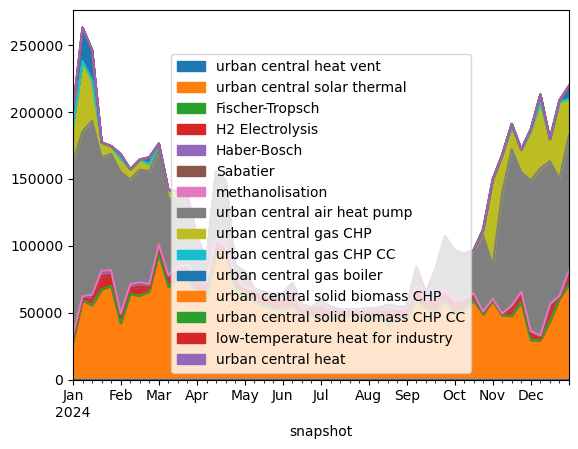

In [425]:
idx = pd.IndexSlice
ss = m.statistics.energy_balance(
    groupby=['bus_carrier', 'carrier'],#, 'bus'],
    aggregate_time=False
    # ).loc[idx[:,'rural heat'], :]
    # ).loc[idx[:,'urban decentral heat'], :]
    ).loc[idx[:,'urban central heat'], :]
ss.index = ss.index.get_level_values(2)
ss = ss.T
ss_pos = ss.clip(lower=0)
ss_neg = ss.clip(upper=0)

fig, ax = plt.subplots()
ss_pos.plot.area(ax=ax, legend=True)
ax.legend()

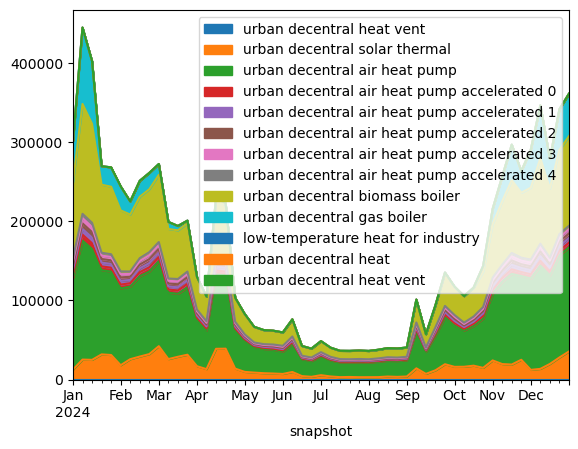

In [426]:
idx = pd.IndexSlice
ss = m.statistics.energy_balance(
    groupby=['bus_carrier', 'carrier'],#, 'bus'],
    aggregate_time=False
    # ).loc[idx[:,'rural heat'], :]
    # ).loc[idx[:,'urban decentral heat'], :]
    ).loc[idx[:,'urban decentral heat'], :]
ss.index = ss.index.get_level_values(2)
ss = ss.T
ss_pos = ss.clip(lower=0)
ss_neg = ss.clip(upper=0)

fig, ax = plt.subplots()
ss_pos.plot.area(ax=ax, legend=True)
ax.legend()

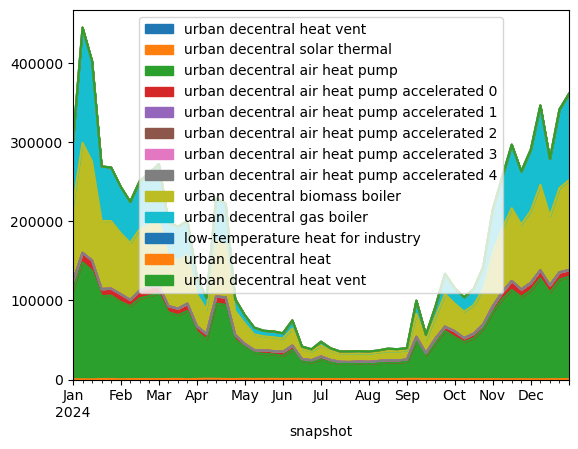

In [412]:
idx = pd.IndexSlice
ss = m.statistics.energy_balance(
    groupby=['bus_carrier', 'carrier'],#, 'bus'],
    aggregate_time=False
    # ).loc[idx[:,'rural heat'], :]
    # ).loc[idx[:,'urban decentral heat'], :]
    ).loc[idx[:,'urban decentral heat'], :]
ss.index = ss.index.get_level_values(2)
ss = ss.T
ss_pos = ss.clip(lower=0)
ss_neg = ss.clip(upper=0)

fig, ax = plt.subplots()
ss_pos.plot.area(ax=ax, legend=True)
ax.legend()

In [430]:
acc_heat_pumps = m.links.loc[m.links.carrier.str.contains('accelerated')].carrier.unique()
acc_heat_pumps

array(['urban decentral air heat pump accelerated 0',
       'urban decentral air heat pump accelerated 1',
       'urban decentral air heat pump accelerated 2',
       'urban decentral air heat pump accelerated 3',
       'urban decentral air heat pump accelerated 4',
       'rural ground heat pump accelerated 0',
       'rural ground heat pump accelerated 1',
       'rural ground heat pump accelerated 2',
       'rural ground heat pump accelerated 3',
       'rural ground heat pump accelerated 4'], dtype=object)

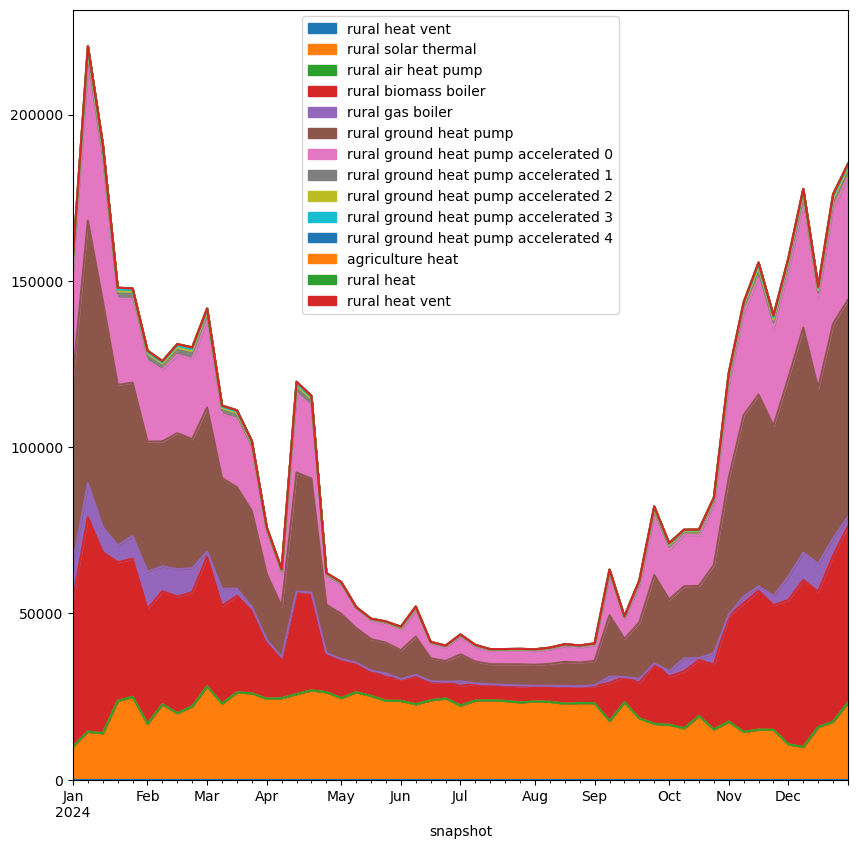

In [416]:
idx = pd.IndexSlice
ss = m.statistics.energy_balance(
    groupby=['bus_carrier', 'carrier'],#, 'bus'],
    aggregate_time=False
    # ).loc[idx[:,'rural heat'], :]
    # ).loc[idx[:,'urban decentral heat'], :]
    ).loc[idx[:,'rural heat'], :]
ss.index = ss.index.get_level_values(2)
ss = ss.T
ss_pos = ss.clip(lower=0)
ss_neg = ss.clip(upper=0)

fig, ax = plt.subplots(figsize=(10, 10))
ss_pos.plot.area(ax=ax, legend=False)
ax.legend(loc='center left', bbox_to_anchor=(2, 0.5))
ax.legend()

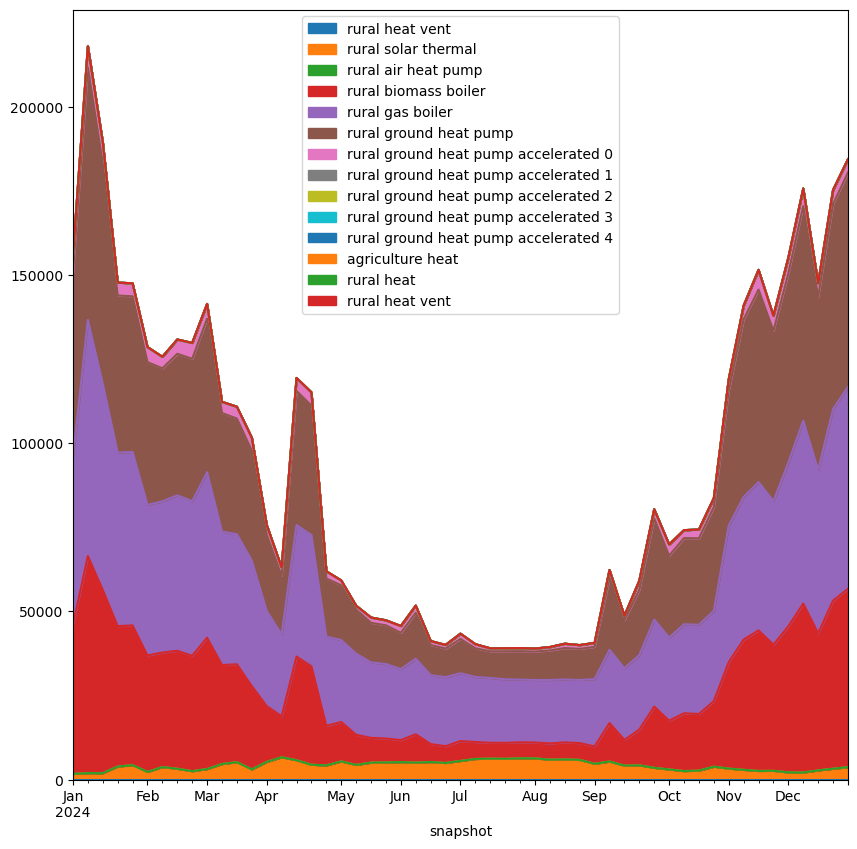

In [411]:
idx = pd.IndexSlice
ss = m.statistics.energy_balance(
    groupby=['bus_carrier', 'carrier'],#, 'bus'],
    aggregate_time=False
    # ).loc[idx[:,'rural heat'], :]
    # ).loc[idx[:,'urban decentral heat'], :]
    ).loc[idx[:,'rural heat'], :]
ss.index = ss.index.get_level_values(2)
ss = ss.T
ss_pos = ss.clip(lower=0)
ss_neg = ss.clip(upper=0)

fig, ax = plt.subplots(figsize=(10, 10))
ss_pos.plot.area(ax=ax, legend=False)
ax.legend(loc='center left', bbox_to_anchor=(2, 0.5))
ax.legend()

In [423]:
bus = 'DE0 0'

hps = [
    template.format(bus) for template in [
        '{} rural ground heat pump',
        '{} rural ground heat pump accelerated 0',
    ]
]
m.links.loc[hps, ['p_nom', 'p_nom_opt', 'p_nom_min', 'p_nom_max']]

,p_nom,p_nom_opt,p_nom_min,p_nom_max
Link,,,,
DE0 0 rural ground heat pump,895.928113,895.928113,0.0,inf
DE0 0 rural ground heat pump accelerated 0,0.000000,852.225353,0.0,985.520925


In [ ]:
cs = pd.Index(n.links.carrier.unique())
uc_carriers = cs[cs.str.contains('urban central')]

Index(['urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC'],
      dtype='object')

In [408]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'low-temperature heat for industry', 'industry electricity',
       'process emissions', 'NH3', 'coal for industry',
       'shipping methanol', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [ ]:
n.loads_